In [102]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from wordcloud import WordCloud
df = pd.read_csv('mental_health_remote_workers_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Employee_ID                       100 non-null    int64 
 1   Name                              100 non-null    object
 2   Age                               100 non-null    int64 
 3   Gender                            100 non-null    object
 4   Country                           100 non-null    object
 5   Job_Role                          100 non-null    object
 6   Experience_Years                  100 non-null    int64 
 7   Work_Mode                         100 non-null    object
 8   Hours_Worked_Per_Week             100 non-null    int64 
 9   Productivity_Score                100 non-null    int64 
 10  Mental_Health_Status              100 non-null    object
 11  Burnout_Score                     100 non-null    int64 
 12  Sleep_Hours_Per_Day    

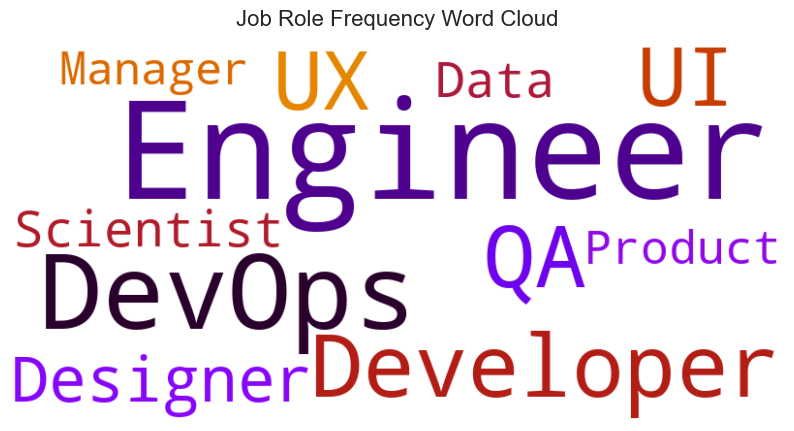

In [138]:
# Job Role Frequencies in a World Cloud

# Create a string of all job roles
job_roles_text = " ".join(df['Job_Role'])

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='gnuplot',
    collocations=False
).generate(job_roles_text)

# Plot word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Job Role Frequency Word Cloud', fontsize=16)
plt.show()

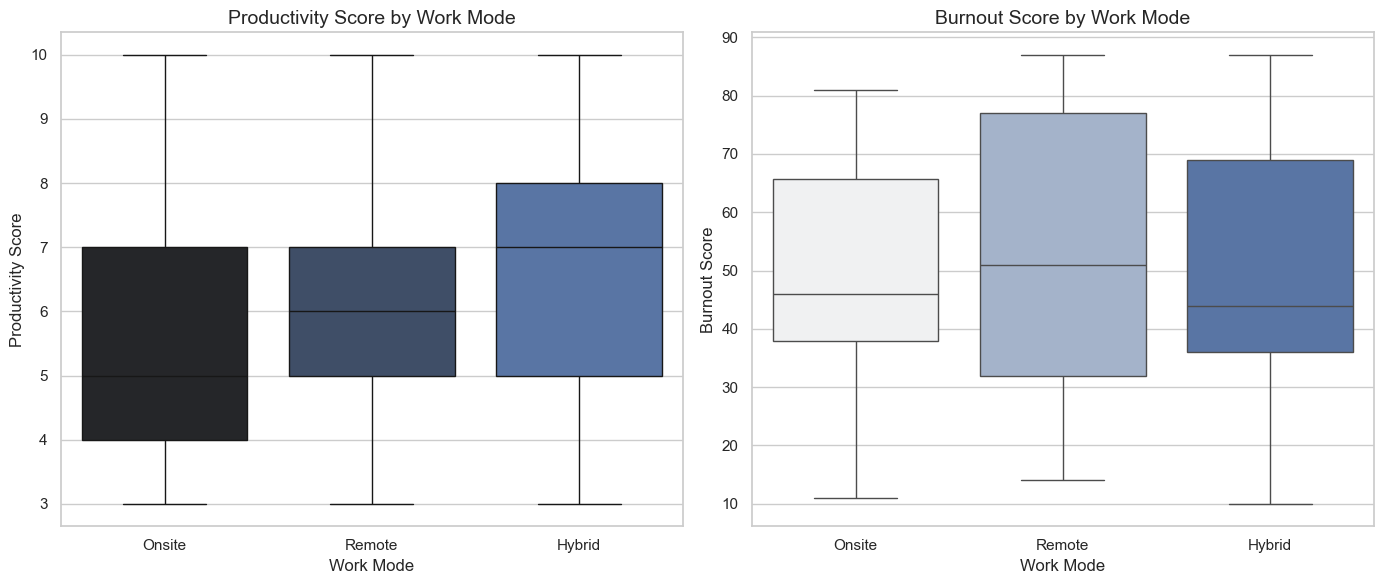

In [52]:
# Productivity score & Burnout score by work mode.

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Box Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    x='Work_Mode', y='Productivity_Score', 
    data=df, palette='dark:b', ax=axes[0], hue = 'Work_Mode', legend = False
)
axes[0].set_title('Productivity Score by Work Mode', fontsize=14)
axes[0].set_xlabel('Work Mode')
axes[0].set_ylabel('Productivity Score')

sns.boxplot(
    x='Work_Mode', y='Burnout_Score', 
    data=df, palette='light:b', ax=axes[1], hue = 'Work_Mode', legend = False
)
axes[1].set_title('Burnout Score by Work Mode', fontsize=14)
axes[1].set_xlabel('Work Mode')
axes[1].set_ylabel('Burnout Score')

plt.tight_layout()
plt.show()

Correlation with Productivity_Score:

Productivity_Score                  1.000000
Work_Life_Balance_Rating            0.106812
Experience_Years                    0.089737
Willing_To_Return_Onsite            0.048859
Sleep_Hours_Per_Day                 0.041468
Team_Communication_Effectiveness    0.030397
Burnout_Score                       0.000846
Hours_Worked_Per_Week              -0.027571
Age                                -0.069589
Remote_Setup_Satisfaction          -0.095616
Employee_ID                        -0.119870
Has_Access_To_Therapist            -0.147474
Name: Productivity_Score, dtype: float64
 


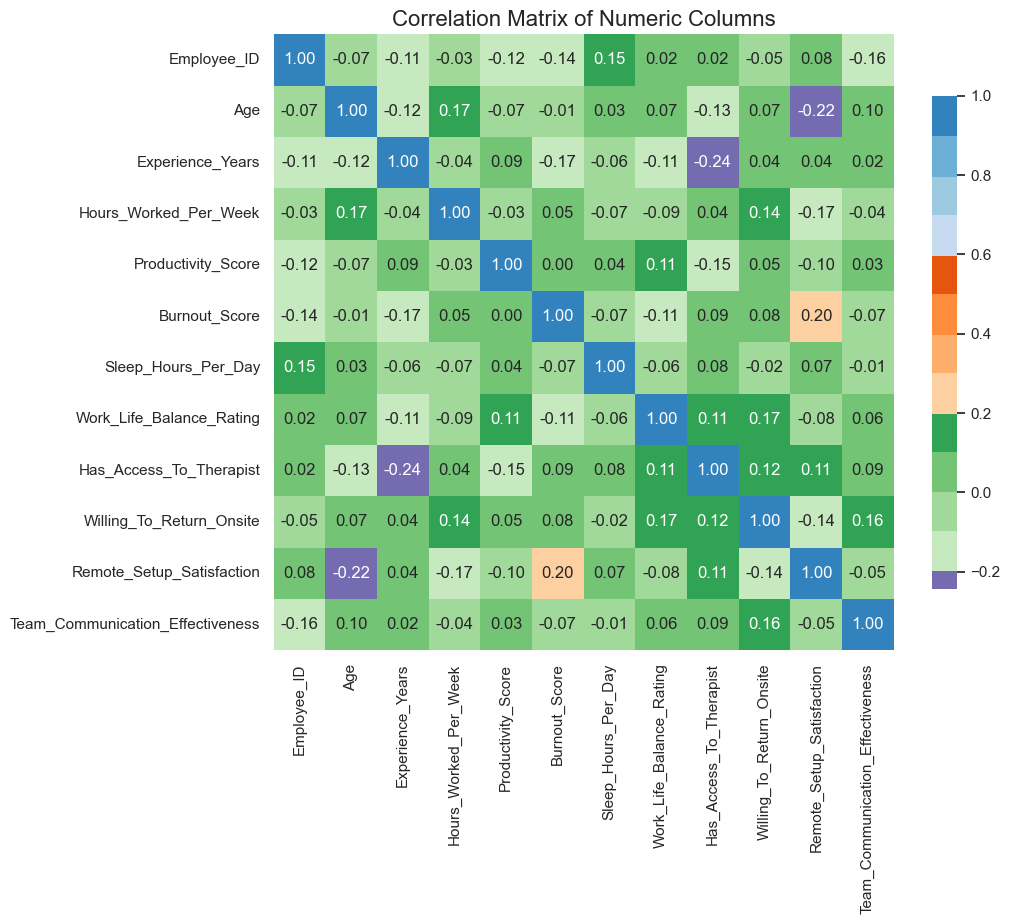

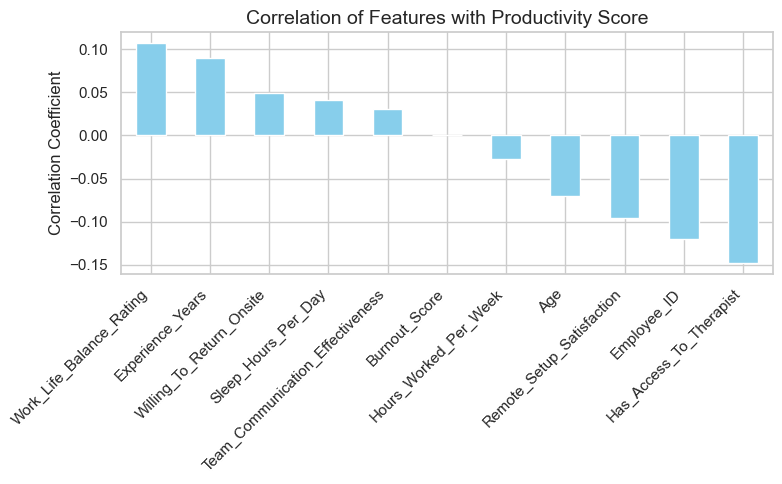

In [66]:
# Correlation Analysis on all Numeric columns
    # What affects productivity the most

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool']).copy()

# Convert boolean columns to integers (True=1, False=0) for correlation
for col in numeric_df.select_dtypes(include='bool'):
    numeric_df[col] = numeric_df[col].astype(int)

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Sort correlations with Productivity_Score
prod_corr = corr_matrix['Productivity_Score'].sort_values(ascending=False)

print("Correlation with Productivity_Score:\n")
print(prod_corr)
print(' ')

# Heatmap Visualization

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='tab20c_r', 
    center=0,
    cbar_kws={'shrink': .8}
)
plt.title('Correlation Matrix of Numeric Columns', fontsize=16)
plt.show()

print(' ')

# Bar Chart for Productivity Correlations

plt.figure(figsize=(8, 5))
prod_corr.drop('Productivity_Score').plot(kind='bar', color='skyblue')
plt.title('Correlation of Features with Productivity Score', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

    Experience_Years  count  mean  median
0                  1      1  72.0    72.0
1                  2     10  54.4    56.0
2                  3      5  57.2    65.0
3                  4      5  71.0    76.0
4                  5      7  49.6    44.0
5                  6      8  63.0    58.0
6                  7      8  35.1    33.0
7                  8      3  26.0    23.0
8                  9     10  48.5    46.0
9                 10      3  51.3    47.0
10                11      3  44.0    38.0
11                12      6  44.8    48.0
12                13      3  27.3    24.0
13                14      5  58.2    45.0
14                15      5  42.6    40.0
15                16      1  71.0    71.0
16                17      6  51.5    49.5
17                18      3  31.3    18.0
18                19      5  48.0    44.0
19                20      3  49.3    59.0
 


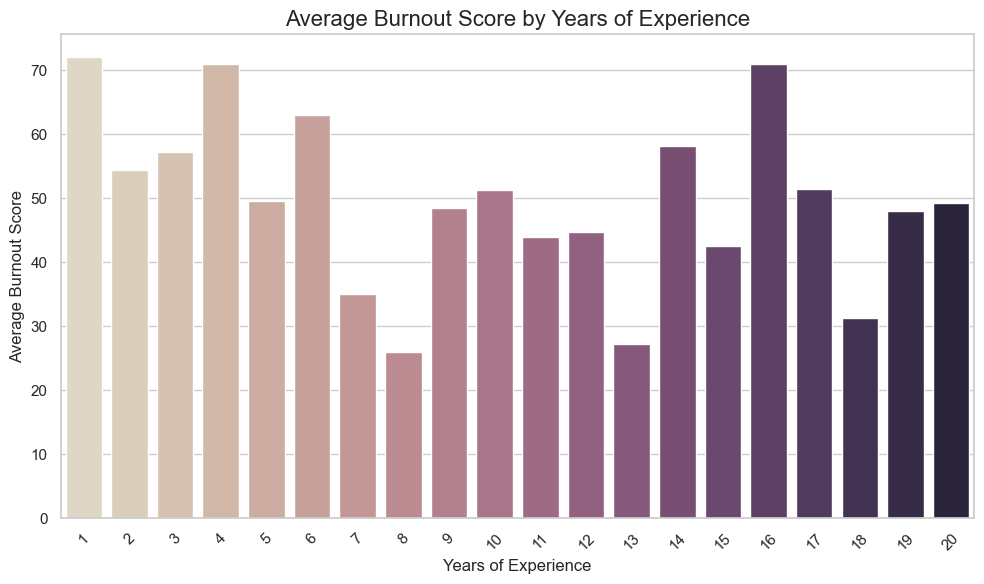

In [78]:
# Analyze Burnout Score by Years of Experience

# Group by Experience_Years and calculate count, mean, and median burnout
burnout_by_exp = (
    df.groupby('Experience_Years')['Burnout_Score']
      .agg(['count', 'mean', 'median'])
      .reset_index()
      .sort_values('Experience_Years')
)

# Round the mean to 2 decimal places
burnout_by_exp['mean'] = burnout_by_exp['mean'].round(1)
print(burnout_by_exp)
print(' ')

# Visualization

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Experience_Years',
    y='mean',
    data=burnout_by_exp,
    palette='ch:s=-.2,r=.6',
    hue='Experience_Years',
    legend=False
)
plt.title('Average Burnout Score by Years of Experience', fontsize=16)
plt.xlabel('Years of Experience')
plt.ylabel('Average Burnout Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

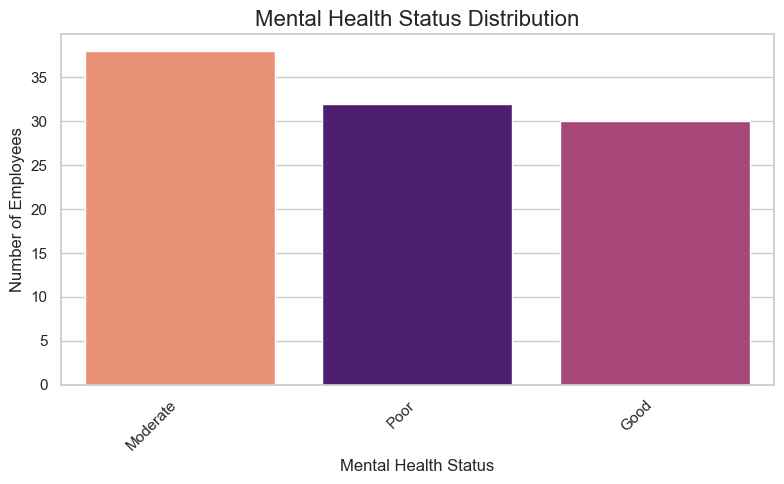

In [90]:
# Mental Health Status

# Set theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(
    x='Mental_Health_Status',
    data=df,
    palette='magma',
    order=df['Mental_Health_Status'].value_counts().index,  # Sort by count
    hue='Mental_Health_Status',
    legend=False
)

plt.title('Mental Health Status Distribution', fontsize=16)
plt.xlabel('Mental Health Status')
plt.ylabel('Number of Employees')

# Rotate x-labels if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

               Gender  Age  Burnout_Score
0              Female   24          60.00
1              Female   25          55.00
2              Female   28          60.50
3              Female   29          61.00
4              Female   30          76.00
..                ...  ...            ...
58  Prefer not to say   42          68.00
59  Prefer not to say   45          10.00
60  Prefer not to say   46          61.25
61  Prefer not to say   47          85.00
62  Prefer not to say   49          43.50

[63 rows x 3 columns]
 


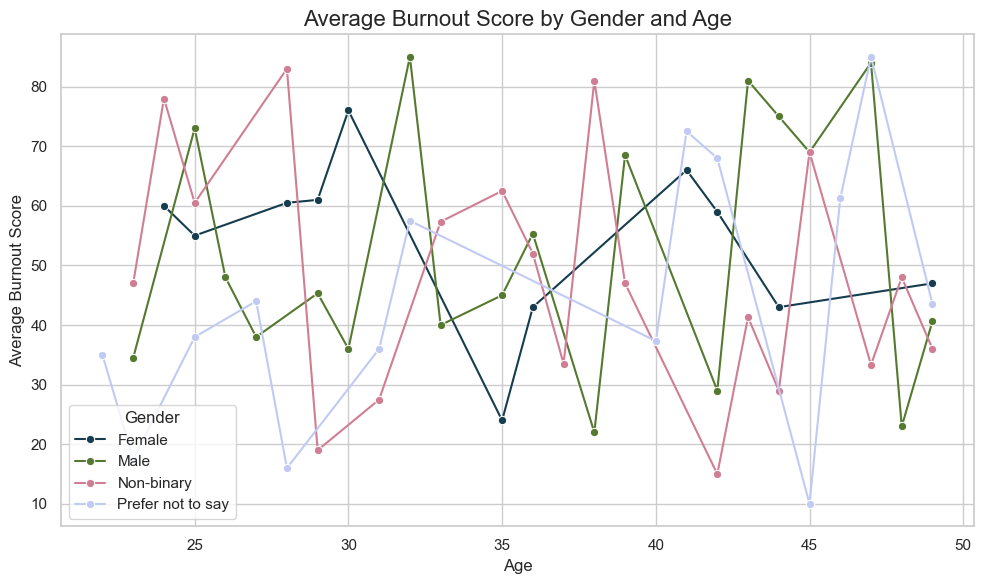

In [96]:
# Average Burnout Score by Gender and Age

# Group by Gender and Age
burnout_by_gender_age = (
    df.groupby(['Gender', 'Age'])['Burnout_Score']
      .mean()
      .reset_index()
)

# Round to 2 decimals for clarity
burnout_by_gender_age['Burnout_Score'] = burnout_by_gender_age['Burnout_Score'].round(2)

print(burnout_by_gender_age)
print(' ')

# Visualization

plt.figure(figsize=(10, 6))
sns.lineplot(
    x='Age',
    y='Burnout_Score',
    hue='Gender',
    data=burnout_by_gender_age,
    marker='o',
    palette='cubehelix'
)

plt.title('Average Burnout Score by Gender and Age', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Average Burnout Score')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

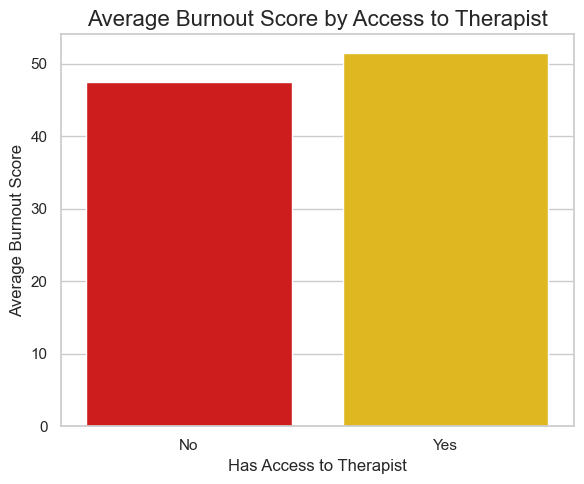

In [122]:
# Compare Burnout Score to those with or without access to a therapist

# Group by Has_Access_To_Therapist and calculate mean burnout
burnout_by_therapist = df.groupby('Has_Access_To_Therapist')['Burnout_Score'].mean().reset_index()
burnout_by_therapist['Burnout_Score'] = burnout_by_therapist['Burnout_Score'].round(2)

# Bar plot
plt.figure(figsize=(6, 5))
sns.barplot(
    x='Has_Access_To_Therapist',
    y='Burnout_Score',
    data=burnout_by_therapist,
    palette='hot',
    hue='Has_Access_To_Therapist',
    legend=False
)

plt.title('Average Burnout Score by Access to Therapist', fontsize=16)
plt.xlabel('Has Access to Therapist')
plt.ylabel('Average Burnout Score')
plt.xticks([0,1], ['No', 'Yes'])
plt.tight_layout()
plt.show()


Work_Life_Balance_Rating  2   3   4   5   6   7   8   9   10
Willing_To_Return_Onsite                                    
False                      1   9   3   8   8   6   5   3   3
True                       4   5   3   4   7   7  11   7   6
 


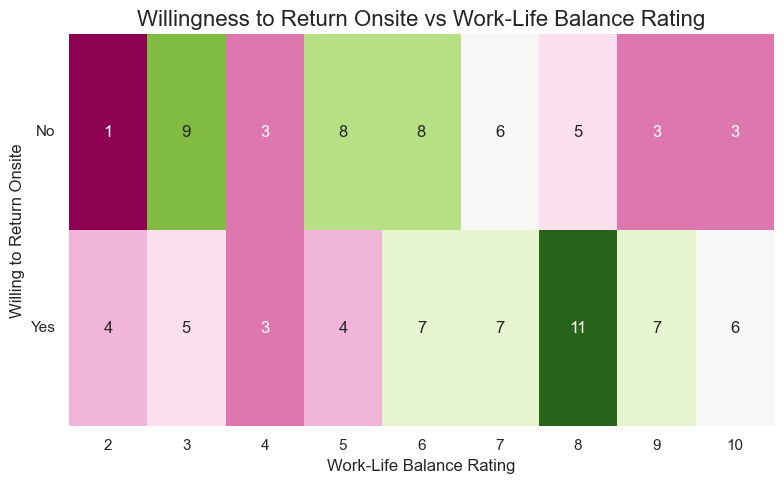

In [128]:
# Crosstab Willing to return onsite vs Work life balance

# Create crosstab
onsite_vs_wlb = pd.crosstab(
    df['Willing_To_Return_Onsite'],
    df['Work_Life_Balance_Rating']
)

print(onsite_vs_wlb)
print(' ')

# Visualize as heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    onsite_vs_wlb, 
    annot=True, 
    fmt='d', 
    cmap='PiYG', 
    cbar=False
)
plt.title('Willingness to Return Onsite vs Work-Life Balance Rating', fontsize=16)
plt.xlabel('Work-Life Balance Rating')
plt.ylabel('Willing to Return Onsite')
plt.yticks([0.5, 1.5], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()


# Mental Health Analysis Summary

## 1. Productivity and Burnout Scores by Work Mode (Box Plot)
- **Productivity Score** ranges:  
  - Onsite: 4–7  
  - Remote: 5–7  
  - Hybrid: 5–8  
- **Burnout Score** ranges:  
  - Onsite: 38–65  
  - Remote: 32–78  
  - Hybrid: 35–69  

**Insight:** Productivity scores are similar across work modes, but burnout is highest for remote employees, suggesting that working remotely may increase stress levels for some.

---

## 2. Correlation Analysis of Numeric Features (Heatmap + Bar Chart)
**Correlation with Productivity Score:**

| Feature                          | Correlation |
|---------------------------------|------------|
| Work_Life_Balance_Rating         | 0.11       |
| Experience_Years                 | 0.09       |
| Willing_To_Return_Onsite         | 0.05       |
| Sleep_Hours_Per_Day              | 0.04       |
| Team_Communication_Effectiveness | 0.03       |
| Burnout_Score                    | 0.00       |
| Hours_Worked_Per_Week            | -0.03      |
| Age                              | -0.07      |
| Remote_Setup_Satisfaction        | -0.10      |
| Employee_ID                      | -0.12      |
| Has_Access_To_Therapist          | -0.15      |

**Insight:** Productivity is slightly higher among employees with better work-life balance and slightly lower burnout. Other factors have minimal impact on productivity in this dataset.

---

## 3. Burnout Score by Years of Experience (Bar Plot)

| Experience_Years | Count | Mean | Median |
|-----------------|-------|------|--------|
| 1               | 1     | 72.0 | 72.0   |
| 2               | 10    | 54.4 | 56.0   |
| 3               | 5     | 57.2 | 65.0   |
| 4               | 5     | 71.0 | 76.0   |
| ...             | ...   | ...  | ...    |
| 20              | 3     | 49.3 | 59.0   |

**Insight:** Burnout is highest among employees with very low (1–4 years) and some very high experience (16 years), while mid-career employees tend to have lower burnout, suggesting early-career adjustment and late-career stress may be key factors.

---

## 4. Mental Health Status Distribution (Count Plot)
- Moderate: 40 employees  
- Poor: 34 employees  
- Good: 30 employees  

**Insight:** Most employees report moderate mental health, but a significant portion report poor mental health, highlighting the need for wellness initiatives.

---

## 5. Average Burnout Score by Gender and Age (Line Plot)

**Insight:**  
- Burnout varies across age and gender.  
- Female employees in their late 20s to 30s show higher burnout, while older employees and those who prefer not to disclose gender show mixed patterns.  
- This suggests that burnout interventions may need to be tailored by age and gender.

---

## 6. Burnout Score by Access to Therapist (Bar Plot)
- No access: 48 employees  
- Yes access: 52 employees  

**Insight:** Employees with access to a therapist show slightly lower burnout scores, indicating that providing mental health support may reduce burnout.

---

## 7. Willingness to Return Onsite vs Work-Life Balance (Heatmap)

| Work_Life_Balance_Rating | 2  | 3  | 4  | 5  | 6  | 7  | 8  | 9  | 10 |
|--------------------------|----|----|----|----|----|----|----|----|----|
| False                    | 1  | 9  | 3  | 8  | 8  | 6  | 5  | 3  | 3  |
| True                     | 4  | 5  | 3  | 4  | 7  | 7  | 11 | 7  | 6  |

**Insight:** Employees with higher work-life balance ratings are generally more willing to return onsite. Those with lower ratings are less willing, suggesting that perceived work-life balance influences willingness to work in-office.

---
